## ASSIGMENT 2

#### Import Library and Dataset

In [1]:
#Import beberapa library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df=pd.read_csv(r'C:\Users\putua\Downloads\p2p_lending.csv') # Import dataset

In [3]:
df.rename(columns={'Status_Peminjaman' : 'Status_Pembayaran'}, inplace = True) #rename columns status peminjaman menjadi status pembayaran 

In [4]:
df.head(10) #Memanggil 10 data teratas dari dataset

,Borrower_ID,Gender,Tipe_Identitas,Wilayah,Status_Pekerjaan,Pendapatan_Bulanan,SIM_Card,Jumlah_Pinjaman,Durasi_Peminjaman,Status_Pembayaran
0,B00001,Female,KTP,Jakarta,Yes,5660000,Telkomsel,1120000,2,No
1,B00002,Male,KTM,Jakarta,No,1540000,Indosat,1250000,2,No
2,B00003,Male,KTP,Banten,Yes,4050000,Telkomsel,1640000,1,No
3,B00004,Female,KTP,Jakarta,Yes,4560000,Telkomsel,810000,2,No
4,B00005,Male,KTP,Jakarta,Yes,4910000,XL,1200000,1,No
5,B00006,Male,KTP,Jakarta,No,960000,Telkomsel,1410000,1,No
6,B00007,Female,KTP,Jakarta,Yes,3180000,Tri,1260000,1,No
7,B00008,Male,KTP,Jakarta,No,2250000,Telkomsel,1240000,1,No
8,B00009,Male,KTP,Jakarta,Yes,4780000,XL,1780000,1,No
9,B00010,Female,KTP,Jakarta,Yes,3740000,Telkomsel,0,2,No


In [5]:
df['Status_Pembayaran'].unique() # Check unique values dari status pembayaran

array(['No', 'Yes'], dtype=object)

In [6]:
df.info() #memunculkan informasi jumlah null values dan tipe dari tiap kolom pada dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Borrower_ID         10000 non-null  object
 1   Gender              10000 non-null  object
 2   Tipe_Identitas      10000 non-null  object
 3   Wilayah             10000 non-null  object
 4   Status_Pekerjaan    10000 non-null  object
 5   Pendapatan_Bulanan  10000 non-null  int64 
 6   SIM_Card            10000 non-null  object
 7   Jumlah_Pinjaman     10000 non-null  int64 
 8   Durasi_Peminjaman   10000 non-null  int64 
 9   Status_Pembayaran   10000 non-null  object
dtypes: int64(3), object(7)
memory usage: 781.4+ KB


### ANALISIS DATA

#### **1. Bagaimana tingkat status gagal bayar yang bervariasi antar wilayah dari borrower**

In [7]:
df['Wilayah'].unique() #Check nilai unik dari kolom wilayah

array(['Jakarta', 'Banten'], dtype=object)

**Check Kualitas Data**

In [8]:
df.isnull().sum() #Check keberadaan variabel null dari tiap kolom

Borrower_ID           0
Gender                0
Tipe_Identitas        0
Wilayah               0
Status_Pekerjaan      0
Pendapatan_Bulanan    0
SIM_Card              0
Jumlah_Pinjaman       0
Durasi_Peminjaman     0
Status_Pembayaran     0
dtype: int64

In [9]:
df.duplicated().sum() #Check apakah terdapat duplicated variabel

np.int64(0)

**Penentuan Model Analisis**

Karena kedua variabel berupa data kategorikal, maka digunakan model chi-square 

**Membangun Hipotesis :** 
- H0 : Tidak ada hubungan antara status gagal bayar dan wilayah
- H1 : Terdapat hubungan antara status gagal bayar dan wilayah

In [10]:
ct = pd.crosstab(df['Wilayah'], df['Status_Pembayaran'])
ct

Status_Pembayaran,No,Yes
Wilayah,,
Banten,4,1
Jakarta,9626,369


In [11]:
#hitung chi square
chi, p, dof, expected = stats.chi2_contingency(ct) 


In [12]:
# Menampilkan hasil 
print('Cross Tabulation :')
print(ct)
print("\nExpected Frequencies")
print(pd.DataFrame(expected, index = ct.index, columns= ct.columns))
print(f'\nChi-square Statistic : {chi:.4f}')
print(f'Degrees of Fredoom : {dof}')
print(f'p-value : {p:.10f}')

Cross Tabulation :
Status_Pembayaran    No  Yes
Wilayah                     
Banten                4    1
Jakarta            9626  369

Expected Frequencies
Status_Pembayaran        No      Yes
Wilayah                             
Banten                4.815    0.185
Jakarta            9625.185  369.815

Chi-square Statistic : 0.5572
Degrees of Fredoom : 1
p-value : 0.4553754636


**Interpretasi Hasil**

In [13]:
if p < 0.05 : 
    print(f'Kesimpulan : Terdapat hubungan antara status pembayaran dan wilayah') #Tolak H0
else : 
    print(f'Tidak terdapat hubungan antara status pembayaran dan wilayah')

Tidak terdapat hubungan antara status pembayaran dan wilayah


**Visualisasi**

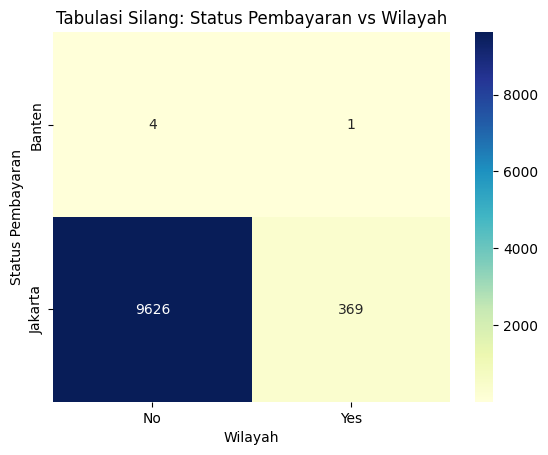

In [14]:
sns.heatmap(data=ct, annot = True,fmt='d', cmap='YlGnBu')
plt.title('Tabulasi Silang: Status Pembayaran vs Wilayah')
plt.xlabel('Wilayah')
plt.ylabel('Status Pembayaran')
plt.show()

**Hasil Analisis** : 
Uji chi-square tidak menunjukkan hubungan yang signifikan antara wilayah dan status pembayaran. Namun, ketimpangan jumlah observasi antar wilayah berpotensi menurunkan kekuatan uji, sehingga hubungan yang lemah atau lokal mungkin tidak terdeteksi.

**Bukti Ketimpangan Jumlah Observasi**

In [15]:
df[df['Wilayah']=='Banten'].count()

Borrower_ID           5
Gender                5
Tipe_Identitas        5
Wilayah               5
Status_Pekerjaan      5
Pendapatan_Bulanan    5
SIM_Card              5
Jumlah_Pinjaman       5
Durasi_Peminjaman     5
Status_Pembayaran     5
dtype: int64

In [16]:
df[df['Wilayah']=='Jakarta'].count()

Borrower_ID           9995
Gender                9995
Tipe_Identitas        9995
Wilayah               9995
Status_Pekerjaan      9995
Pendapatan_Bulanan    9995
SIM_Card              9995
Jumlah_Pinjaman       9995
Durasi_Peminjaman     9995
Status_Pembayaran     9995
dtype: int64

Terlihat bahwa data wilayah Banten hanya berjumlah 5, sedangkan wilayah Jakarta berjumlah 9995.


#### **2. Apakah ada perbedaan rata-rata penghasilan antara peminjam yang gagal bayar dan yang sukses membayar?**

**Check Kualitas data**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Borrower_ID         10000 non-null  object
 1   Gender              10000 non-null  object
 2   Tipe_Identitas      10000 non-null  object
 3   Wilayah             10000 non-null  object
 4   Status_Pekerjaan    10000 non-null  object
 5   Pendapatan_Bulanan  10000 non-null  int64 
 6   SIM_Card            10000 non-null  object
 7   Jumlah_Pinjaman     10000 non-null  int64 
 8   Durasi_Peminjaman   10000 non-null  int64 
 9   Status_Pembayaran   10000 non-null  object
dtypes: int64(3), object(7)
memory usage: 781.4+ KB


**Menentukan Model uji :**
- Karena membandingkan rata-rata dari variabel numerik (pendapatan) di antara dua kelompok yang saling bebas atau tidak berhubungan maka uji yang digunakan adalah `Independent Sample t-test`

**HIPOTESIS :** 
- H0 : Tidak terdapat perbedaan rata-rata penghasilan antara peminjam gagal bayar dan peminjam lunas
- H1 : Terdapat perbedaan rata-rata penghasilan antara peminjam gagal bayar dan lunas

<Axes: xlabel='Pendapatan_Bulanan'>

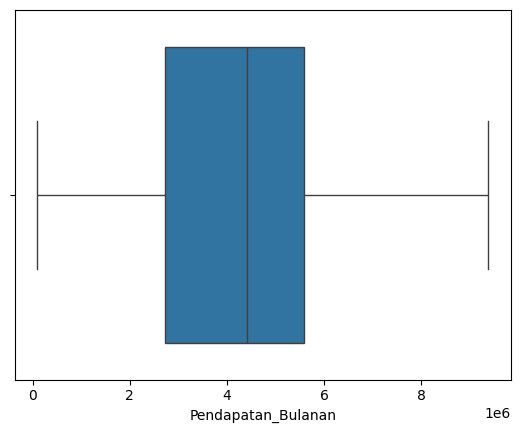

In [18]:
# Check Outliers
sns.boxplot(data=df,x="Pendapatan_Bulanan")

**Hasil Analisi :**
Tidak terdapat outlier untuk data pendapatan bulanan

In [19]:
from scipy.stats import ttest_ind #import ttest_ind untuk scipy.stats

In [20]:
#Pisahkan data
grup_gagal_bayar = df[df['Status_Pembayaran']=='Yes']['Pendapatan_Bulanan']
grup_lunas = df[df['Status_Pembayaran']=='No']['Pendapatan_Bulanan']

In [21]:
#Uji T-Test
stat, p = ttest_ind(grup_gagal_bayar,grup_lunas, equal_var=False)

In [22]:
#Menentukan nilai p-value
print(f'P-value : {p:.10f}')

P-value : 0.0000358143


In [23]:
# Interpertasi hasil
if p < 0.05 : 
    print('Terdapat Perbedaan Rata-Rata Pendapatan Antara Peminjam Gagal Bayar dan Lunas')
else : 
    print('Tidak Terdapat Perbedaan Rata-Rata Pendapatan Antara Peminjam Gagal Bayar dan Lunas')

Terdapat Perbedaan Rata-Rata Pendapatan Antara Peminjam Gagal Bayar dan Lunas


**Perbedaan mean antara dua grup**

In [24]:
mean_gagal_bayar = grup_gagal_bayar.mean()
mean_lunas = grup_lunas.mean()
print(f'Rata-rata pendapatan gagal bayar : {mean_gagal_bayar:.4f}')
print(f'Rata-rata pendapatan tidak gagal bayar : {mean_lunas:.4f}')

Rata-rata pendapatan gagal bayar : 3897513.5135
Rata-rata pendapatan tidak gagal bayar : 4290911.7342


In [25]:
selisih_mean = mean_lunas - mean_gagal_bayar
print(f'Selisih rata-rata antara gagal bayar dan lunas : {selisih_mean:.4f}')

Selisih rata-rata antara gagal bayar dan lunas : 393398.2207


**Visualisasi Perbedaan Rata-Rata**

In [26]:
mean_df = df.groupby('Status_Pembayaran')['Pendapatan_Bulanan'].mean()

In [27]:
mean_df

Status_Pembayaran
No     4.290912e+06
Yes    3.897514e+06
Name: Pendapatan_Bulanan, dtype: float64

In [28]:
mean_df = (
    df
    .groupby('Status_Pembayaran', as_index=False)['Pendapatan_Bulanan']
    .mean()
)
mean_df


,Status_Pembayaran,Pendapatan_Bulanan
0,No,4.290912e+06
1,Yes,3.897514e+06


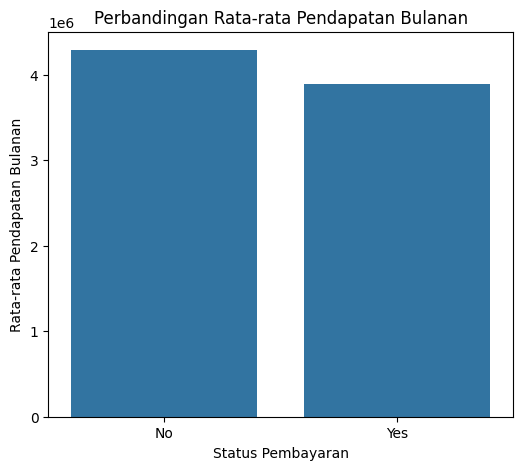

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.barplot(
    data=mean_df,
    x='Status_Pembayaran',
    y='Pendapatan_Bulanan'
)

plt.title('Perbandingan Rata-rata Pendapatan Bulanan')
plt.xlabel('Status Pembayaran')
plt.ylabel('Rata-rata Pendapatan Bulanan')
plt.show()


Dari hasil uji analisis yang telah dilakukan dapat disimpulkan bahwa : terdapat perbedaan rata-rata pendapatan bulanan yang mana borrower yang memiliki status pembayaran 'No' atau lunas itu memiliki pendapatan yang lebih tinggi. Adapun perbedaan pendapatan bulanan rata-rata dari borrower adalah ``393398.2207``

#### **3. Strategi Apa yang bisa dilakukan agar borrower tidak Melakukan Gagal Bayar**

**EDA**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Borrower_ID         10000 non-null  object
 1   Gender              10000 non-null  object
 2   Tipe_Identitas      10000 non-null  object
 3   Wilayah             10000 non-null  object
 4   Status_Pekerjaan    10000 non-null  object
 5   Pendapatan_Bulanan  10000 non-null  int64 
 6   SIM_Card            10000 non-null  object
 7   Jumlah_Pinjaman     10000 non-null  int64 
 8   Durasi_Peminjaman   10000 non-null  int64 
 9   Status_Pembayaran   10000 non-null  object
dtypes: int64(3), object(7)
memory usage: 781.4+ KB


**Penjelasan** 
- Terlihat bahwa tidak terdapat null values pada tiap variabel. 
- Terdapat 4 variabel bertipe numerik dan 6 variabel bertipe object 

**Groupby**

In [31]:
df.groupby('Status_Pembayaran')['Pendapatan_Bulanan'].mean()

Status_Pembayaran
No     4.290912e+06
Yes    3.897514e+06
Name: Pendapatan_Bulanan, dtype: float64

**Penjelasan** 
- Pendapatan bulanan borrower dengan status pembayaran No : Lunas lebih tingi dibandingkan borrower yang belum lunas. 
- Perbedaan rata-rata antara kedua borrower tidak terlalu berbeda secara signifikan. 

In [32]:
df.groupby('Status_Pembayaran')['Jumlah_Pinjaman'].mean()

Status_Pembayaran
No     1.223671e+06
Yes    2.718838e+06
Name: Jumlah_Pinjaman, dtype: float64

**Penjelasan**
- Jumlah pinjaman borrower belum lunas lebih tinggi secara signifikan dibandingkan dengan borrower yang sudah lunas.

In [33]:
df.groupby('Status_Pembayaran')['Durasi_Peminjaman'].mean()

Status_Pembayaran
No     2.063448
Yes    9.294595
Name: Durasi_Peminjaman, dtype: float64

**Penjelasan**
- Terlihat bahwa lama waktu pinjaman borrower tidak lunas jauh lebih lama dibandingkan dengan borrower lunas.

**Visualisasi Boxplot**

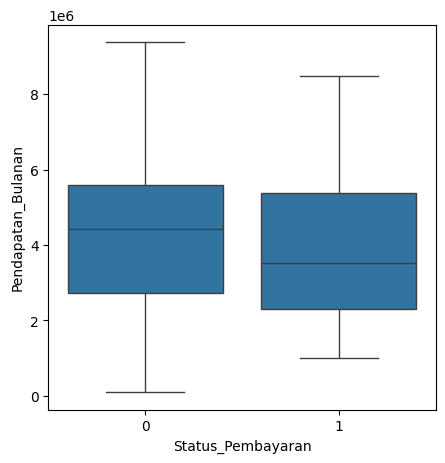

In [69]:
fig,ax = plt.subplots(figsize=(5,5))
sns.boxplot(data = df, x ='Status_Pembayaran', y ='Pendapatan_Bulanan')
plt.show()

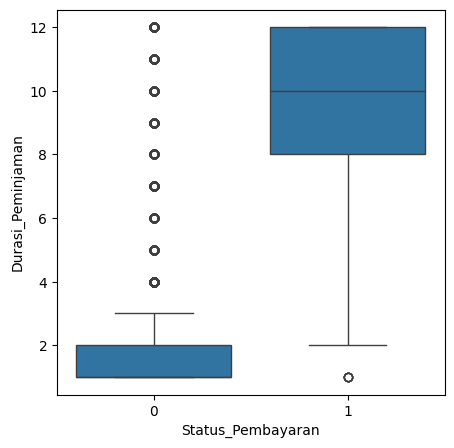

In [70]:
fig,ax = plt.subplots(figsize=(5,5))
sns.boxplot(data = df, x ='Status_Pembayaran', y ='Durasi_Peminjaman')
plt.show()

Masih terdapat outlier dalam durasi peminjaman

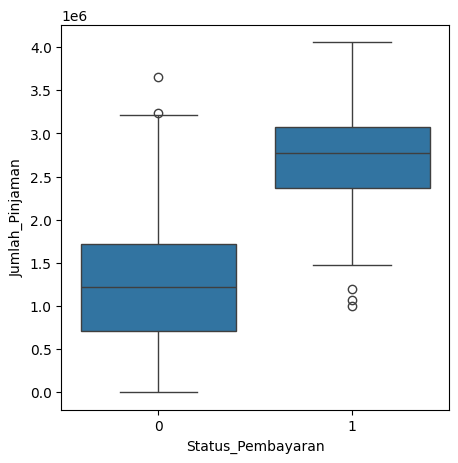

In [71]:
fig,ax = plt.subplots(figsize=(5,5))
sns.boxplot(data = df, x ='Status_Pembayaran', y ='Jumlah_Pinjaman')
plt.show()

#### Analisis Model

#### 
**Model yang dipakai : ``Logistic Regression``**

**Encode Target : Status Pembayaran**

In [35]:
 df['Status_Pembayaran']= df['Status_Pembayaran'].map({
   'Yes' : 1, #Gagal bayar
   'No' : 0}) #Lunas

In [36]:
df['Status_Pembayaran'].unique()

array([0, 1])

**Menentukan Variabel**

In [37]:
x = df[['Pendapatan_Bulanan',
       'Jumlah_Pinjaman', 
       'Durasi_Peminjaman', 
       'Status_Pekerjaan', 
       'Wilayah',
       'Gender']]

y = df['Status_Pembayaran']

**Encoding Variabel Kategori**

In [38]:
x= pd.get_dummies(x, drop_first=True)

**Split Data**

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state= 100, 
    stratify=y

)

**Bangun Model Logistic Regression**

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter = 1000,
    class_weight='balanced'
)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

**Evaluasi Model**

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[1807  119]
 [   7   67]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1926
           1       0.36      0.91      0.52        74

    accuracy                           0.94      2000
   macro avg       0.68      0.92      0.74      2000
weighted avg       0.97      0.94      0.95      2000



**Intepretasi Koefisien**

In [42]:
coef_df = pd.DataFrame({
    'Variabel' : x.columns,
    'Coeficient' : model.coef_[0]
})

coef_df['Odds_Ratio']= np.exp(coef_df['Coeficient'])
coef_df = coef_df.sort_values(by ='Odds_Ratio', ascending=False)

coef_df

,Variabel,Coeficient,Odds_Ratio
2,Durasi_Peminjaman,6.099255e-01,1.840294
3,Status_Pekerjaan_Yes,5.129034e-01,1.670133
1,Jumlah_Pinjaman,2.783726e-06,1.000003
0,Pendapatan_Bulanan,-2.252145e-07,1.000000
5,Gender_Male,-2.616333e+00,0.073070
4,Wilayah_Jakarta,-3.270003e+00,0.038006


**Strategi yang Mesti Diterapkan Perusahaan**

- 1. ``Durasi Peminjaman`` : Setiap kenaikan 1 unit durasi peminjaman, meningkatkan odds gagal bayar sebesar 84%, dengan asumsi bahwa variabel lain konstan. 

- 2. ``Status Pekerjaan`` : Peminjam dengan status pekerjaan = Yes memiliki odds gagal bayar 67% lebih tinggi dibandingkan dengan baseline. 
**Catatan : Yes, diartikan di sini sebagai pekerjaan tidak tetap**

- 3. ``Jumlah Pinjaman`` : Berdasarkan hasilnya, pengaruhnya sangat kecil kurang dari 1%. 

- 4. ``Gender : Male`` : Peminjam laki-laki memiliki odds gagal bayar ~93% lebih rendah dibandingkan dengan peminjam perempuan. 

- 5. ``Wilayah : Jakarta`` : Memiliki odds gagal bayar ~96% lebih rendah dibandingkan wilayah baselinenya yaitu Banten. 


**Check Kesesuaian Logika**

In [43]:
df.groupby('Status_Pembayaran').agg({
    'Pendapatan_Bulanan': 'mean',
    'Jumlah_Pinjaman': 'mean',
    'Durasi_Peminjaman': 'mean'
})


,Pendapatan_Bulanan,Jumlah_Pinjaman,Durasi_Peminjaman
Status_Pembayaran,,,
0,4.290912e+06,1.223671e+06,2.063448
1,3.897514e+06,2.718838e+06,9.294595


**Strategi yang Bisa Diterapkan Oleh Perusahaan Berdasarkan EDA dan Logistic Regression**

**Strategi 1**

Perusahaan perlu mengendalikan tenor, yaitu : 
- 1. Membatasai tenor maksimum untuk peminjam baru
- 2. Tenor panjang itu harusnya hanya untuk peminjam dengan histori penghasilan yang kuat``

**Strategi 2**

Screening berdasarkan Status Pekerjaan : 
- 1. Pekerjaan tidak tetap diberikan pinjaman lebih kecil dan tenor pinjaman lebih pendek. 

- 2. Pekerjaan tetap diberikan fleksibilitas yang lebih besar sesuai dengan kemampuan bayar peminjam

**Strategi 3** 

Segmentasi Wilayah : 
- 1. Wilayah beresiko gagal bayar tinggi perlu monitoring lebih sering, tenor lebih pendek, dan perlu diadakan edukasi finansial

- 2. Wilayah rendah risiko diperlukan usaha perusahaan untuk memproses lebih cepat pinjaman untuk menjaga kepercayaan peminjam. 

## Analisis Tambahan (STATISTICAL PRACTICAL)

**1. Apakah terdapat perbedaan rata-rata jumlah pinjaman antara pria dan wanita?
``Metode: Independent Samples t-test.``**

**Check Kualitas Data**

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Borrower_ID         10000 non-null  object
 1   Gender              10000 non-null  object
 2   Tipe_Identitas      10000 non-null  object
 3   Wilayah             10000 non-null  object
 4   Status_Pekerjaan    10000 non-null  object
 5   Pendapatan_Bulanan  10000 non-null  int64 
 6   SIM_Card            10000 non-null  object
 7   Jumlah_Pinjaman     10000 non-null  int64 
 8   Durasi_Peminjaman   10000 non-null  int64 
 9   Status_Pembayaran   10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [45]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

<Axes: ylabel='Jumlah_Pinjaman'>

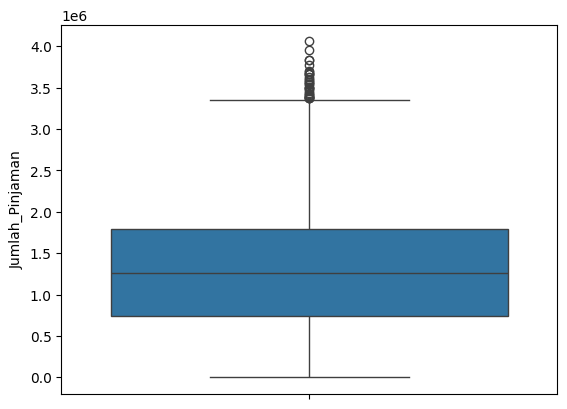

In [46]:
sns.boxplot(df['Jumlah_Pinjaman'])

Dari hasil visualisasi menunjukkan bahwa memang masih terdapat outlier, tetapi outlier ini menunjukkan jumlah pinjaman yang jumlahnya memang lebih banyak dibandingkan dengan jumlah pinjaman lainnya. Sehingga outlier ini tetap dipakai. 

In [47]:
from scipy.stats import ttest_ind #import library

In [48]:
female= df[df['Gender']=='Female']['Jumlah_Pinjaman']
male = df[df['Gender']=='Male']['Jumlah_Pinjaman']

In [49]:

stat, p = ttest_ind(female,male, equal_var=False)

In [50]:
print(f'p-value : {p:.2f}')

p-value : 0.68


**Bangun Hipotesis :** 
- H0 : Tidak terdapat perbedaan rata-rata jumlah pinjaman antara laki-laki dan perempuan
- H1 : Terdapat perbedaan rata-rata jumlah pinjaman antara laki-laki dan perempuan

In [51]:
if p < 0.05 : 
    print('Terdapat perbedaan rata-rata jumlah pinjaman berdasarkan gender')
else : 
    print('Tidak Terdapat perbedaan Rata-rata jumlah pinjaman berdasarkan gender')

Tidak Terdapat perbedaan Rata-rata jumlah pinjaman berdasarkan gender


In [52]:
female_mean = female.mean()
male_mean = male.mean()

print(f'Rata-Rata Pinjaman Perempuan : {female_mean:.5f}')
print(f'Rata-rata pinjaman laki-laki : {male_mean:.5f}')

Rata-Rata Pinjaman Perempuan : 1283331.30884
Rata-rata pinjaman laki-laki : 1276861.48800


In [53]:
mean_pinjaman_gender = df.groupby('Gender', as_index = False)['Jumlah_Pinjaman'].mean()

In [54]:
mean_pinjaman_gender

,Gender,Jumlah_Pinjaman
0,Female,1.283331e+06
1,Male,1.276861e+06


In [55]:
selisih_mean_pinjaman_gender =female_mean- male_mean

In [56]:
print(f'Rata-ratra jumlah pinjaman perempuan lebih besar sebesar {selisih_mean_pinjaman_gender:.4f} dibandingkan dengan laki-laki')

Rata-ratra jumlah pinjaman perempuan lebih besar sebesar 6469.8208 dibandingkan dengan laki-laki


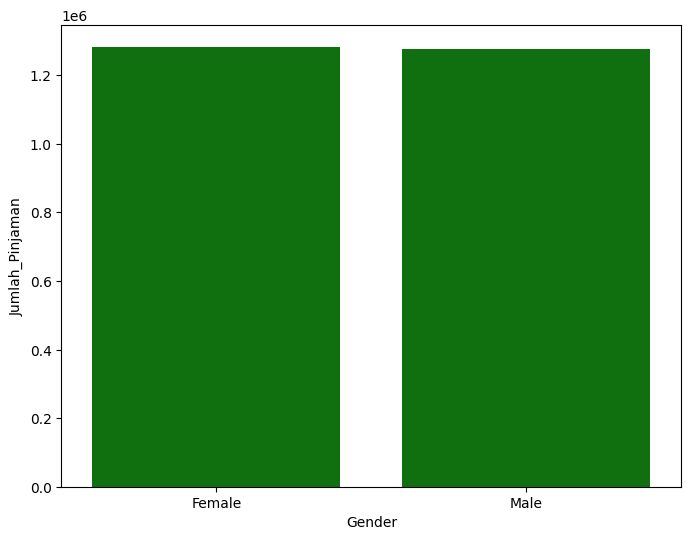

In [57]:
plt.figure(figsize=(8,6))
sns.barplot(data = mean_pinjaman_gender,
            x= 'Gender', 
            y = 'Jumlah_Pinjaman', color ='green')

plt.xlabel = 'Gender'
plt.ylabel = 'Jumlah Pinjaman'
plt.title = 'Distribusi Perbedaan Rata-Rata Jumlah Pinjaman Berdasarkan Gender'
plt.show()

Berdasarkan uji Welch’s t-test, diperoleh p-value > 0.05 sehingga H0 gagal ditolak. Hal ini menunjukkan bahwa tidak terdapat perbedaan rata-rata jumlah pinjaman antara borrower laki-laki dan perempuan yang mana rata-rata jumlah pinjaman borrower perempuan lebih besar dibandingkan laki-laki tetapi selisihnya tidak terlalu signifikan, yaitu hanya sebesar ``6469.8208``

**2. Apakah pendapatan berbeda berdasarkan status pekerjaan?
Metode: Independent Samples t-test.**

In [58]:
df['Status_Pekerjaan'].unique() #Melihat info variabel yang digunakan 

array(['Yes', 'No'], dtype=object)

**Membangun Interpretasi Data Variabel Status Pekerjaan**
- `Yes` : Pekerjaan tidak tetap 
- `No` : Pekerjaan Tetap

In [59]:
from scipy.stats import ttest_ind

In [60]:
status_yes = df[df['Status_Pekerjaan']=='Yes']['Pendapatan_Bulanan']
status_no = df[df['Status_Pekerjaan']=='No']['Pendapatan_Bulanan']

In [61]:

stat, p = ttest_ind(status_no, status_yes, equal_var=False)

In [62]:

print(f'p_value : {p:.4f}')

p_value : 0.0000


**Bangun Hipotesis:** 
- H0 : Tidak terdapat perbedaan rata-rata jumlah pendapatan berdasarkan status pekerjaan.
- H1 : Terdapat perbedaan rata-rata jumlah pendapatan berdasarkan status pekerjaan

In [63]:
if p <0.05 : 
    print('Terdapat perbedaan rata-rata jumlah pendapatan berdasarkan status pekerjaan')
else : 
    print('Tidak terdapat perbedaan rata-rata jumlah berdasarkan status pekerjaan')

Terdapat perbedaan rata-rata jumlah pendapatan berdasarkan status pekerjaan


In [64]:
mean_yes = status_yes.mean()
mean_no = status_no.mean()
selisih_status_mean = mean_yes - mean_no

print(f'Jumlah pendapatan rata-rata peminjam dengan status pekerjaan tidak tetap : {mean_yes:.4f}')
print(f'Jumlah pendapatan rata-rata peminjam dengan status pekerjaan tetap : {mean_no}')
print(f'Selisih rata-rata pendapatan berdasarkan status pekerjaan : {selisih_status_mean:.4f}')

Jumlah pendapatan rata-rata peminjam dengan status pekerjaan tidak tetap : 5105009.9206
Jumlah pendapatan rata-rata peminjam dengan status pekerjaan tetap : 2290288.722826087
Selisih rata-rata pendapatan berdasarkan status pekerjaan : 2814721.1978


In [65]:
mean_pendapatan_status = df.groupby('Status_Pekerjaan', as_index=False)['Pendapatan_Bulanan'].mean()
mean_pendapatan_status

,Status_Pekerjaan,Pendapatan_Bulanan
0,No,2.290289e+06
1,Yes,5.105010e+06


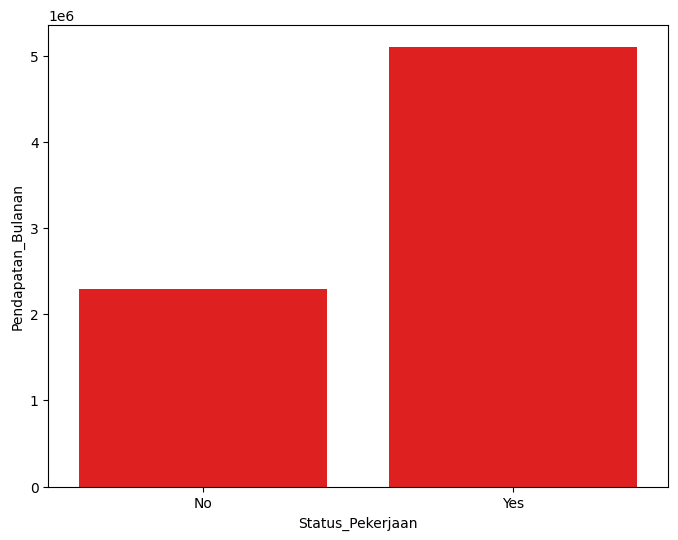

In [66]:
plt.figure(figsize=(8,6))
sns.barplot(data =mean_pendapatan_status, x ='Status_Pekerjaan', y='Pendapatan_Bulanan', color ='red')
plt.xlabel = "Status Pekerjaan"
plt.ylabel = 'Pendapatan Bulanan Peminjam'
plt.title = 'Distribusi Pendapatan Bulanan Berdasarkan Status Pekerjaan'
plt.show()

Berdasarkan hasil uji yang menunjukkan bahwa nilai p-value < 0.05 yang artinya H0 berhasil ditolak, maka model menunjukkan bahwa memang terdapat perbedaan jumlah pendapatan bulanan berdasarkan status pekerjaan. Status pekerjaan 'Yes' memiliki jumlah pendapatan bulanan yang lebih tinggi dibandingkan dengan peminjam dengan status pekerjaan 'No'